# Prueba - Análisis estadístico con Python
## Daniel Rojas López

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sci

### 1. Carga los datos y explóralos. Elimina los datos nulos o incorrectos


In [2]:
# Cargar el dataset de salarios
df = pd.read_csv("cardio.csv",delimiter=',')
df.shape


(4238, 16)

In [3]:
#eliminar datos nulos o incorrectos
df = df.dropna()
df.shape

(3656, 16)

### 2. Escoge tres variables cuantitativas y realiza un análisis descriptivo de ellas, utilizando indicadores y gráficos. ¿Cuaĺ presenta mayor dispersión?


In [4]:
df.head(10)

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,F,43,2.0,No,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,F,63,1.0,No,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,F,45,2.0,Yes,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,M,52,1.0,No,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,M,43,1.0,Yes,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [5]:
df_edad = df[['age']].copy()
mean_edad = df_edad['age'].mean()
std_edad = df_edad['age'].std()
df_edad.describe()




,age
count,3656.000000
mean,49.557440
std,8.561133
min,32.000000
25%,42.000000
50%,49.000000
75%,56.000000
max,70.000000


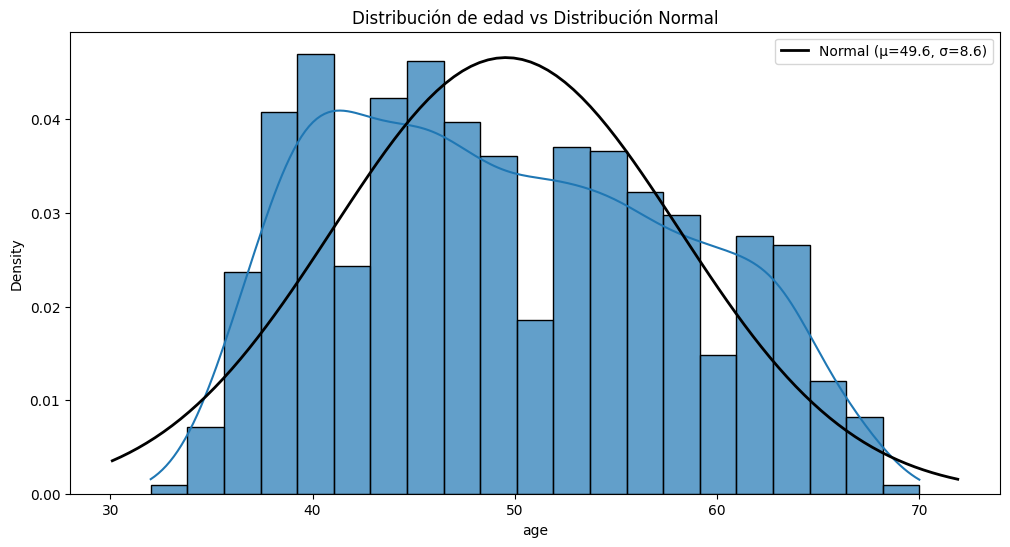

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(df_edad['age'], kde=True, stat='density', alpha=0.7)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = sci.norm.pdf(x, mean_edad, std_edad)  # Ahora sí funcionará
plt.plot(x, p, 'k', linewidth=2, label=f'Normal (μ={mean_edad:.1f}, σ={std_edad:.1f})')
plt.legend()
plt.title('Distribución de edad vs Distribución Normal')
plt.show()  

In [7]:
df_pulsaciones_corazon = df[['heartRate']].copy()
df_pulsaciones_corazon.describe()

,heartRate
count,3656.000000
mean,75.730580
std,11.982952
min,44.000000
25%,68.000000
50%,75.000000
75%,82.000000
max,143.000000


In [8]:
df_gludosa = df[['glucose']].copy()
df_gludosa.describe()

,glucose
count,3656.000000
mean,81.856127
std,23.910128
min,40.000000
25%,71.000000
50%,78.000000
75%,87.000000
max,394.000000


In [ ]:

# se seleccionan las columnas numéricas elegidas para verificar si existe correlación entre ellas
df_seleccionada = df[['age', 'heartRate', 'glucose']].copy()
df_seleccionada.head()


,age,heartRate,glucose
0,39,80.0,77.0
1,46,95.0,76.0
2,48,75.0,70.0
3,61,65.0,103.0
4,46,85.0,85.0


In [14]:
for col in df_seleccionada.columns:
    if df_seleccionada[col].dtype == 'object':
        # Remover símbolos de porcentaje, comas y otros caracteres
        df_seleccionada[col] = df_seleccionada[col].astype(str).str.replace('%', '').str.replace(',', '').str.replace('$', '').str.replace(' ', '')
        # Convertir a numérico
        df_seleccionada[col] = pd.to_numeric(df_seleccionada[col], errors='coerce')

# Calcular matriz de correlación
correlation_matrix = df_seleccionada.corr()

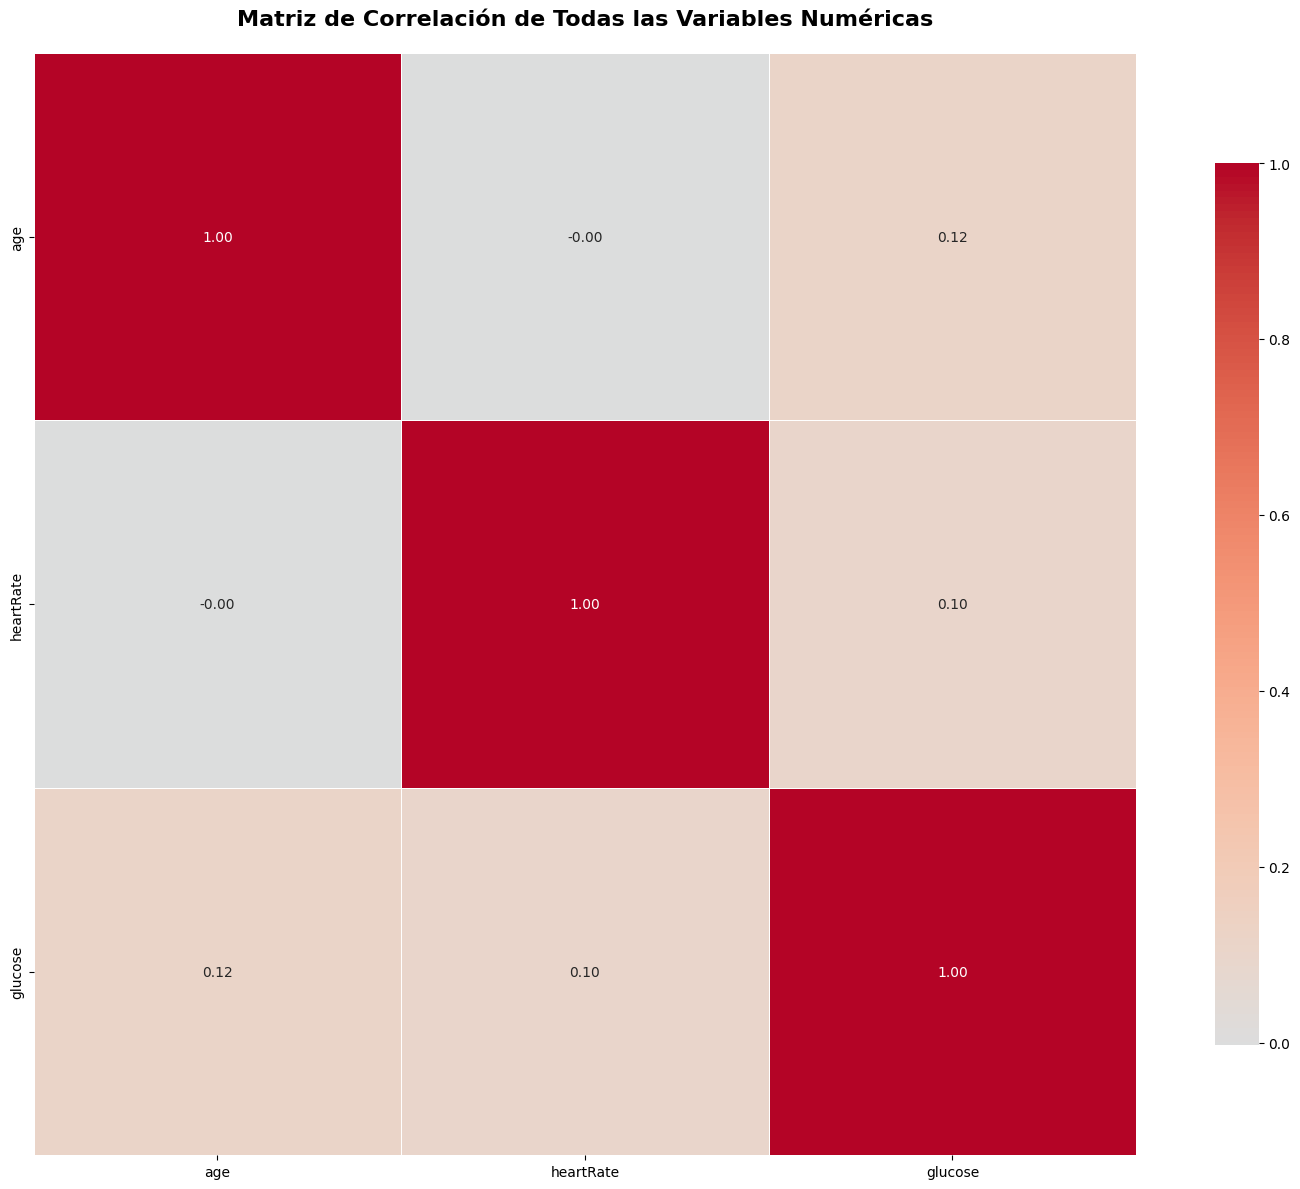

In [15]:
# Crear el heatmap
plt.figure(figsize=(16, 12))

# Configurar el heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores de correlación
    cmap='coolwarm',      # Esquema de colores (rojo=positivo, azul=negativo)
    center=0,             # Centrar el colormap en 0
    square=True,          # Hacer las celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={"shrink": 0.8},  # Configurar barra de color
    fmt='.2f'            # Formato de números (2 decimales)
)

plt.title('Matriz de Correlación de Todas las Variables Numéricas', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

No existe una correlación significativa entre las variables numéricas del dataset.

### 3. Elimina los datos atípicos del dataset. Para las siguientes preguntas, considera el dataset "limpio"


In [10]:
#eliminar datos atipicos de la columna age 

# calculando IQR por age
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# definiendo los bounds de los outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# removiendo los outliers
df_limpio = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

print(f"Original dataset size: {len(df)}")
print(f"Clean dataset size: {len(df_limpio)}")
print(f"Removed outliers: {len(df) - len(df_limpio)}")

Original dataset size: 3656
Clean dataset size: 3656
Removed outliers: 0


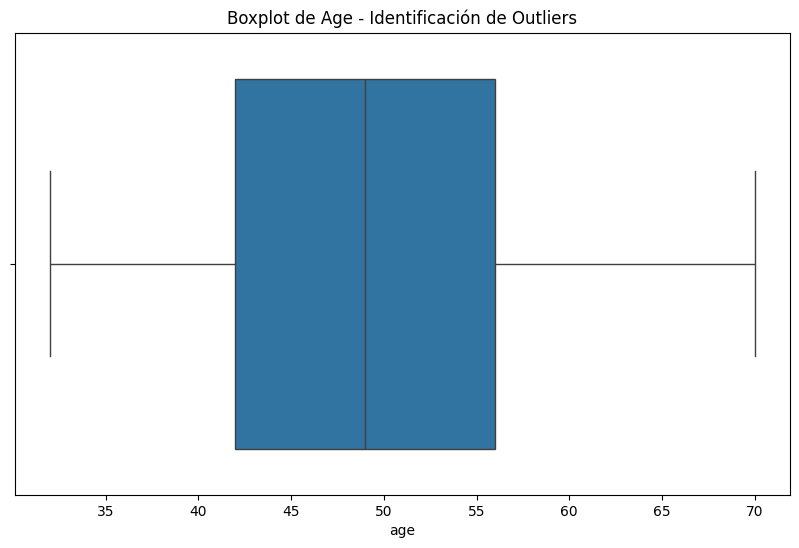

In [11]:
# Boxplot to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['age'])
plt.title('Boxplot de Age - Identificación de Outliers')
plt.show()

# Then apply IQR method
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['age'] >= Q1 - 1.5 * IQR) & (df['age'] <= Q3 + 1.5 * IQR)]

### 4. ¿Qué variables cuantitativas presentan mayor correlación? Explica.


In [12]:
# Seleccionar solo columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Limpiar y convertir datos numéricos
df_numeric = df[numeric_columns].copy()

# Convertir columnas con símbolos y formato
for col in df_numeric.columns:
    if df_numeric[col].dtype == 'object':
        # Remover símbolos de porcentaje, comas y otros caracteres
        df_numeric[col] = df_numeric[col].astype(str).str.replace('%', '').str.replace(',', '').str.replace('$', '').str.replace(' ', '')
        # Convertir a numérico
        df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

# Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

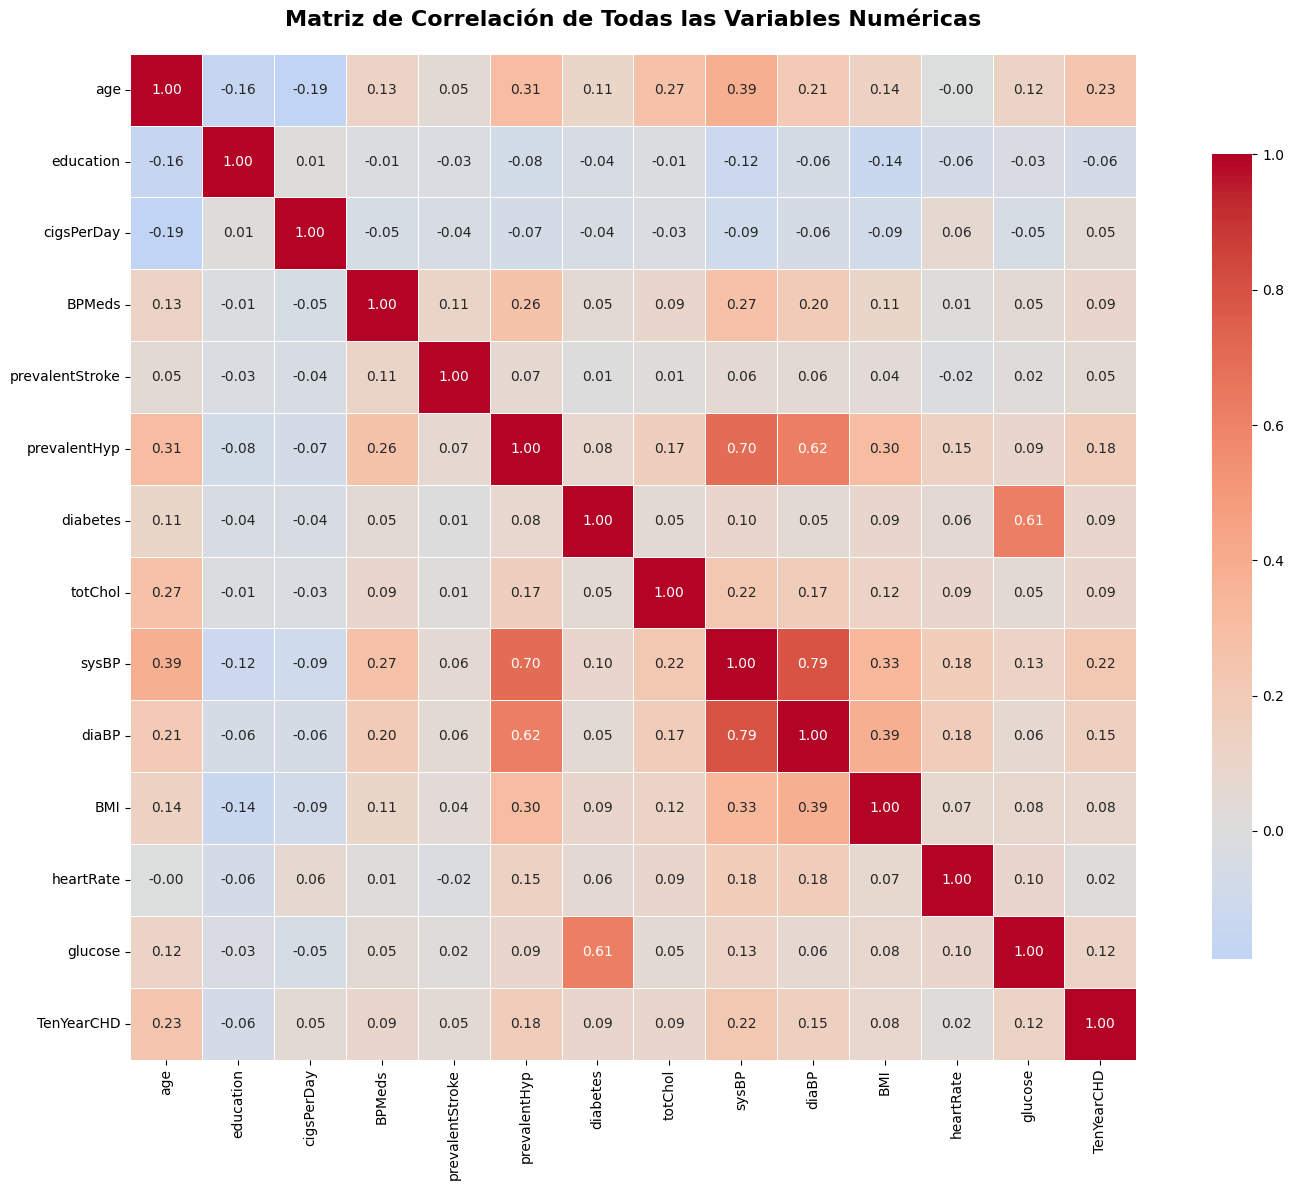

In [13]:
# Crear el heatmap
plt.figure(figsize=(16, 12))

# Configurar el heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores de correlación
    cmap='coolwarm',      # Esquema de colores (rojo=positivo, azul=negativo)
    center=0,             # Centrar el colormap en 0
    square=True,          # Hacer las celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={"shrink": 0.8},  # Configurar barra de color
    fmt='.2f'            # Formato de números (2 decimales)
)

plt.title('Matriz de Correlación de Todas las Variables Numéricas', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Entre las variable que mas correlacion tienen con la variable target son:
sysBP y diaBP
sysBP y prevalentHyp

y las que menos correlacion tienen son:
CigsPerDay y age



### 5. Si de este dataset se escoge un paciente al azar, ¿cuál es la probabilidad de que sea hombre, si se sabe que pertenece al mayor cuartil de la variable correspondiente al índice de masa corporal?


### 6. ¿Es razonable afirmar que, para una persona cualquiera (no necesariamente dentro del dataset), su ritmo cardiaco promedio es 75? Explica y justifica.


### 7. Ser hombre, ¿influye en el promedio de cigarrillos consumidos por día, dentro de los pacientes fumadores? Explica.


### 8. Construye un modelo de regresión lineal que permita relacionar 6 variables del dataset con el índice de masa corporal. (Debes incluir al menos dos variables cualitativas). Evalúa tu modelo y explica.


### 9. Construye un modelo de regresión logística para predecir el riesgo de sufrir una enfermedad coronaria en los próximos diez años, a partir de las variables descritas. Verifica el balanceo de datos y evalúa tu modelo.


### 10. Separa los modelos de regresión anteriores en dos distintos, respectivamente, considerando alguna variable categórica. Compara y concluye